# Genetic Rock Paper Scissors

The original paper shows how, in a _three-way_ prey-predator model, the
unexpected emerging behavior is a sort of _survival of the weakest_, where the
least aggressive species are the ones the most likely will have an higher
population density.

The model does not involve movement but only space conquering by hunting a
nearby cell, which will host the offspring of the predator. The offspring
inherit the invasion probability from the father

- Just by copying it:
  $$ p_\text{new} = p_\text{old} $$
- With a random mutation:
  $$ p_\text{new} = p_\text{old} + \varepsilon $$
  with $\varepsilon \sim \cal{N} (0, 0.05)$

The study shows mainly two cases: 

- Two of the three species invasion probability are held constant, while the
  third is free to evolve through random mutations.
- All three species are free to mutate.

The paper also says how the mutation, in general, drive the population to be
more aggressive on average, that results in:

- A reduced population of the specie free to evolve (first case).
- A dynamical equilibrium, made possible by all three species reaching maximal
  aggression (second case).

In [1]:
import pandas as pd
from grps.utils import (
    plot_densities,
    plot_average_invasions,
    plot_average_age,
    plot_orbits,
)

## Paper Results Reproduction

The first thing to do is to have a baseline by reproducing the dynamics
described in the paper on a $75 \times 75$ and a maximum of $500$ epochs
simulation. 

The grid is randomly initialized by sampling one of the three species for each
cell with equal probability.

### Inheritance

The first case of study assigns at each specie individual an invasion
probability, which will inhertied by their offsprings after the reproduction.

Here the goal is just to reproduce the main result of the paper (survival of the
weakest), by assigning a lower invasion probability to one of the three species
and see if in the end it has the highest population density.

In [12]:
in_df = pd.read_csv("results/inheritance.csv")
in_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy
0,1802,1934,1889,0.2,0.5,0.5,0.000000,0.000000,0.000000,0,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
1,1668,1829,2128,0.2,0.5,0.5,1.000000,1.000000,1.000000,1,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
2,1549,1730,2346,0.2,0.5,0.5,1.932860,1.873410,1.863171,2,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3,1472,1657,2496,0.2,0.5,0.5,2.766984,2.646349,2.655849,3,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
4,1415,1516,2694,0.2,0.5,0.5,3.547703,3.351583,3.346696,4,0,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,2560,951,2114,0.2,0.5,0.5,18.758984,7.093586,20.196310,995,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3996,2542,955,2128,0.2,0.5,0.5,18.803698,7.144503,19.880169,996,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3997,2515,958,2152,0.2,0.5,0.5,19.009145,7.132568,19.680297,997,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance
3998,2512,975,2138,0.2,0.5,0.5,19.056131,7.326154,19.646866,998,3,75,0.2,0.5,0.5,inheritance,inheritance,inheritance


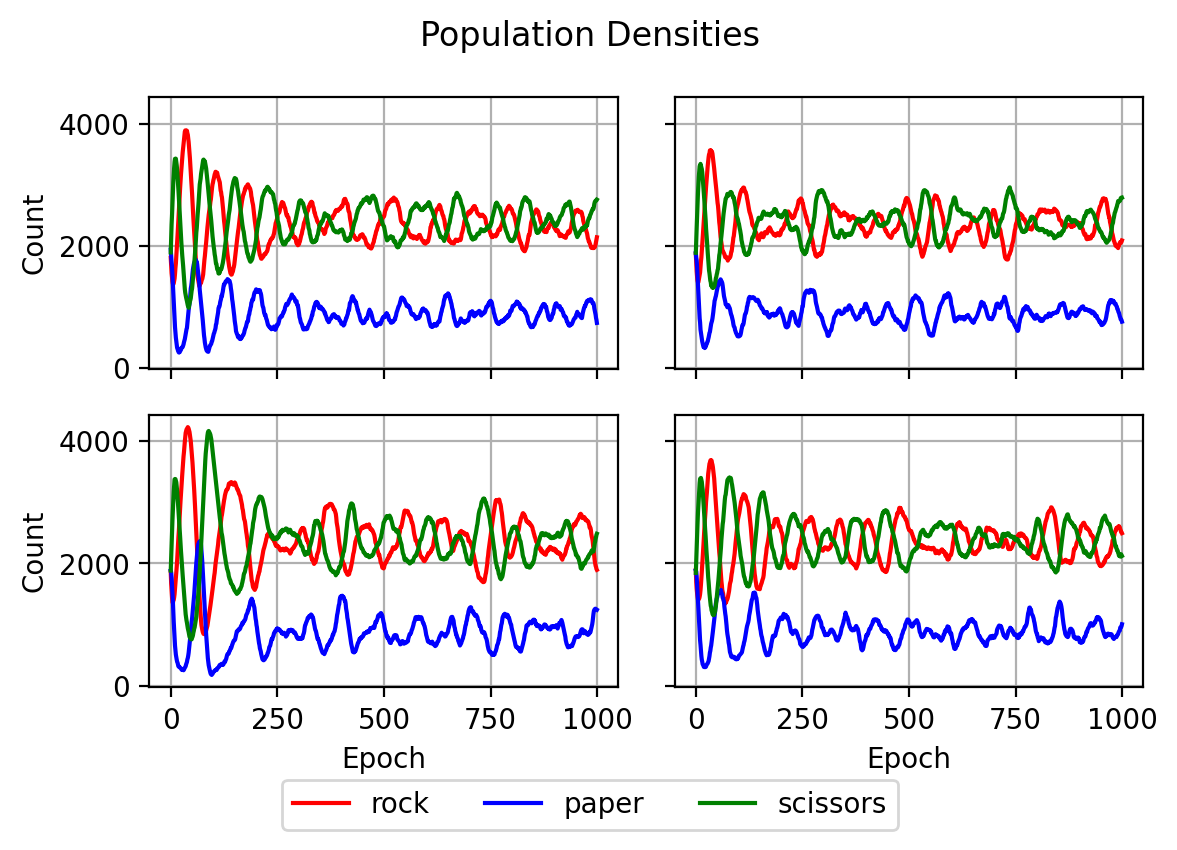

In [13]:
plot_densities(in_df)

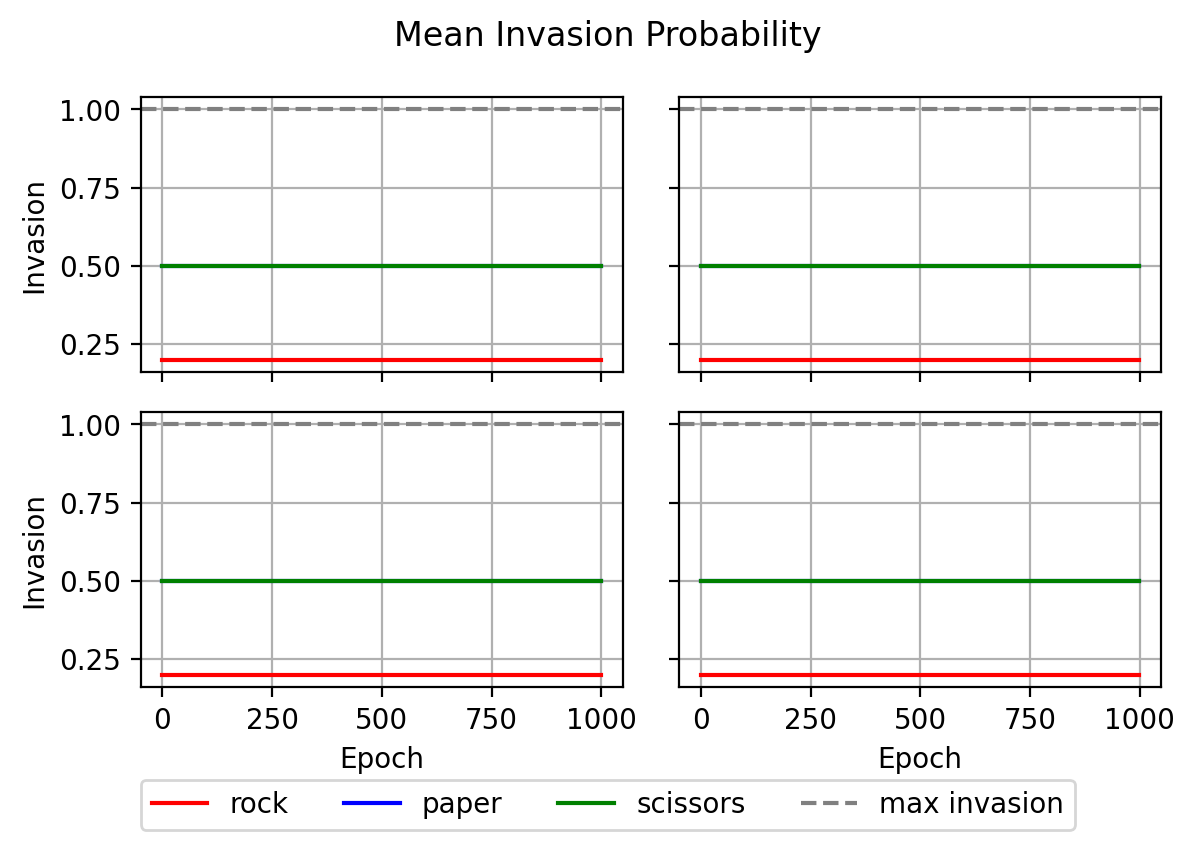

In [14]:
plot_average_invasions(in_df)

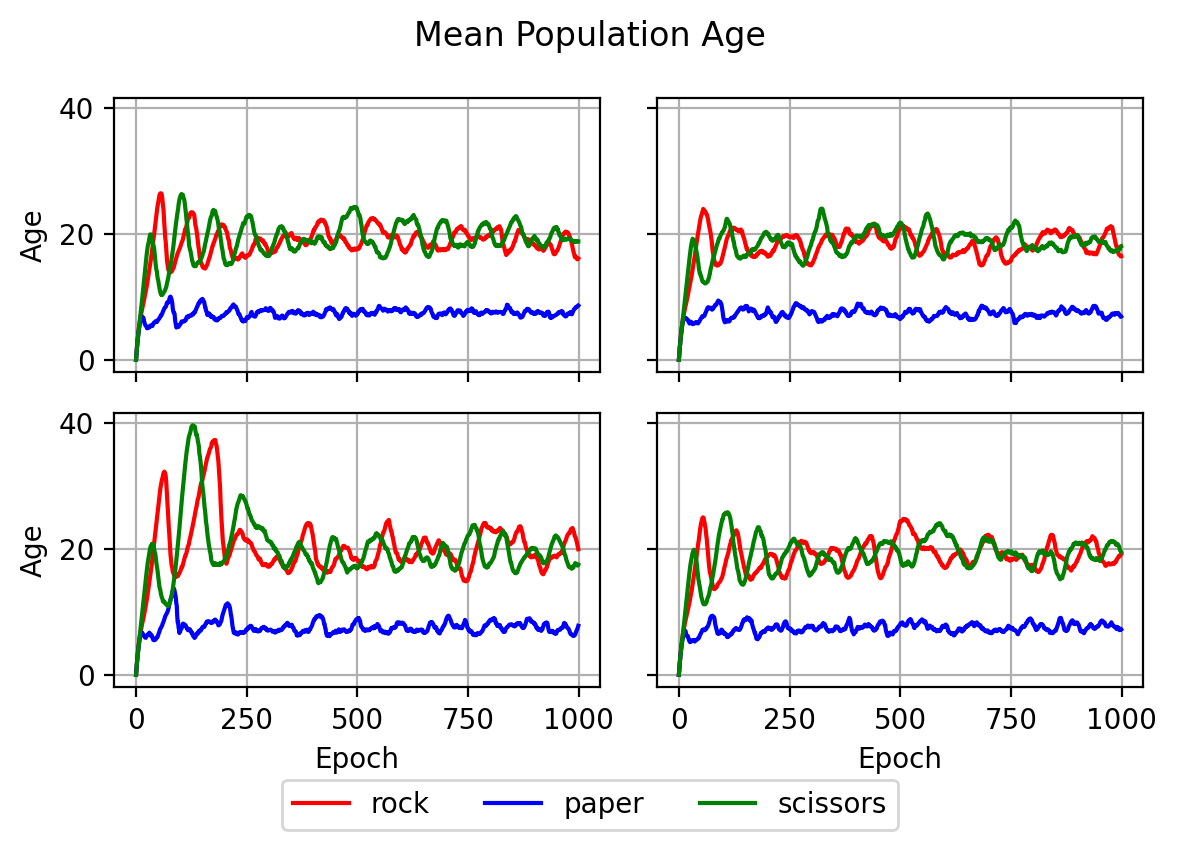

In [15]:
plot_average_age(in_df)

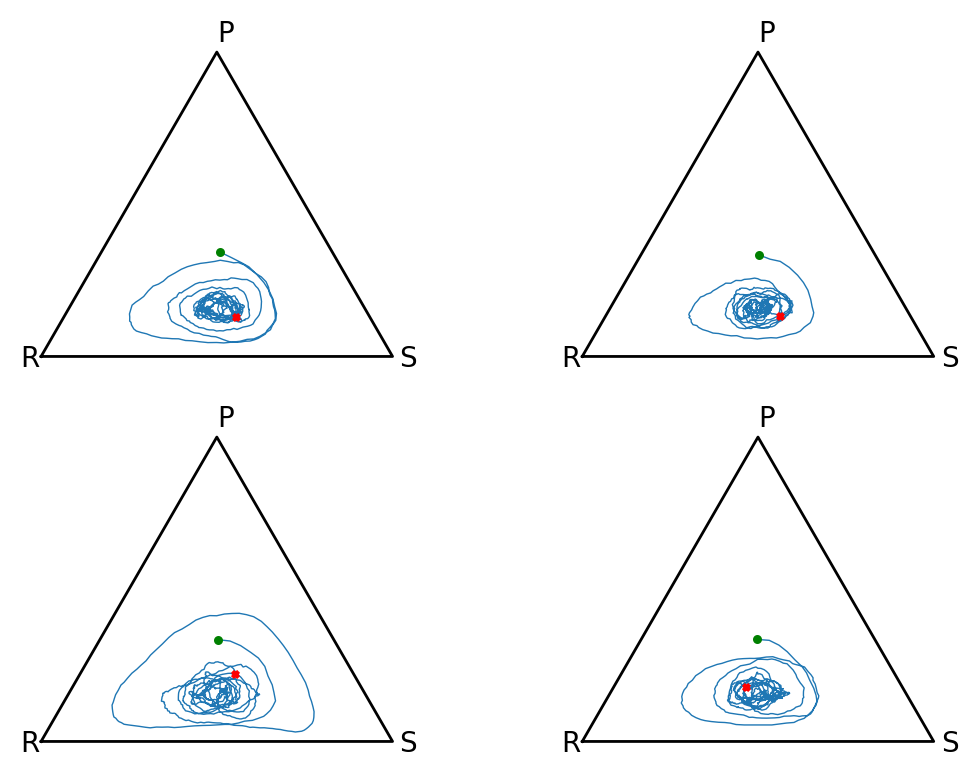

In [16]:
plot_orbits(in_df)

### Stochastic Mutation of 1 Specie

The other main result shown was obtained by keeping two species invasion
probabilites fixed, while the third is let free to mutate.

Here the end result can vary, depending on initial conditions and initial
invasion probabilities assigned to each specie.

In the following simulations are shown two main scenarios:

- Every specie starts with an initial invasion rate of $0.5$.
- The evolvable specie starts with a low invasion rate of $0.2$.

The two models might converge to the same result, since in the paper is said
that the mutated specie tends to be more aggressive in the end.

In [7]:
s1_df = pd.read_csv("results/stochastic1.csv")
s1_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma
0,1802,1934,1889,0.200000,0.5,0.5,0.000000,0.000000,0.000000,0,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1,1665,1843,2117,0.200098,0.5,0.5,1.000000,1.000000,1.000000,1,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
2,1536,1753,2336,0.200505,0.5,0.5,1.933594,1.869367,1.861729,2,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
3,1444,1670,2511,0.200496,0.5,0.5,2.788089,2.647904,2.646356,3,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
4,1398,1534,2693,0.200465,0.5,0.5,3.537911,3.341591,3.340884,4,0,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1682,2680,1263,0.875217,0.5,0.5,6.867420,9.927239,6.336500,495,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1996,1661,2711,1253,0.878136,0.5,0.5,6.855509,9.994098,6.160415,496,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1997,1644,2732,1249,0.877722,0.5,0.5,6.875304,10.135432,6.099279,497,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1998,1647,2717,1261,0.878436,0.5,0.5,6.875531,10.170777,5.898493,498,3,75,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05


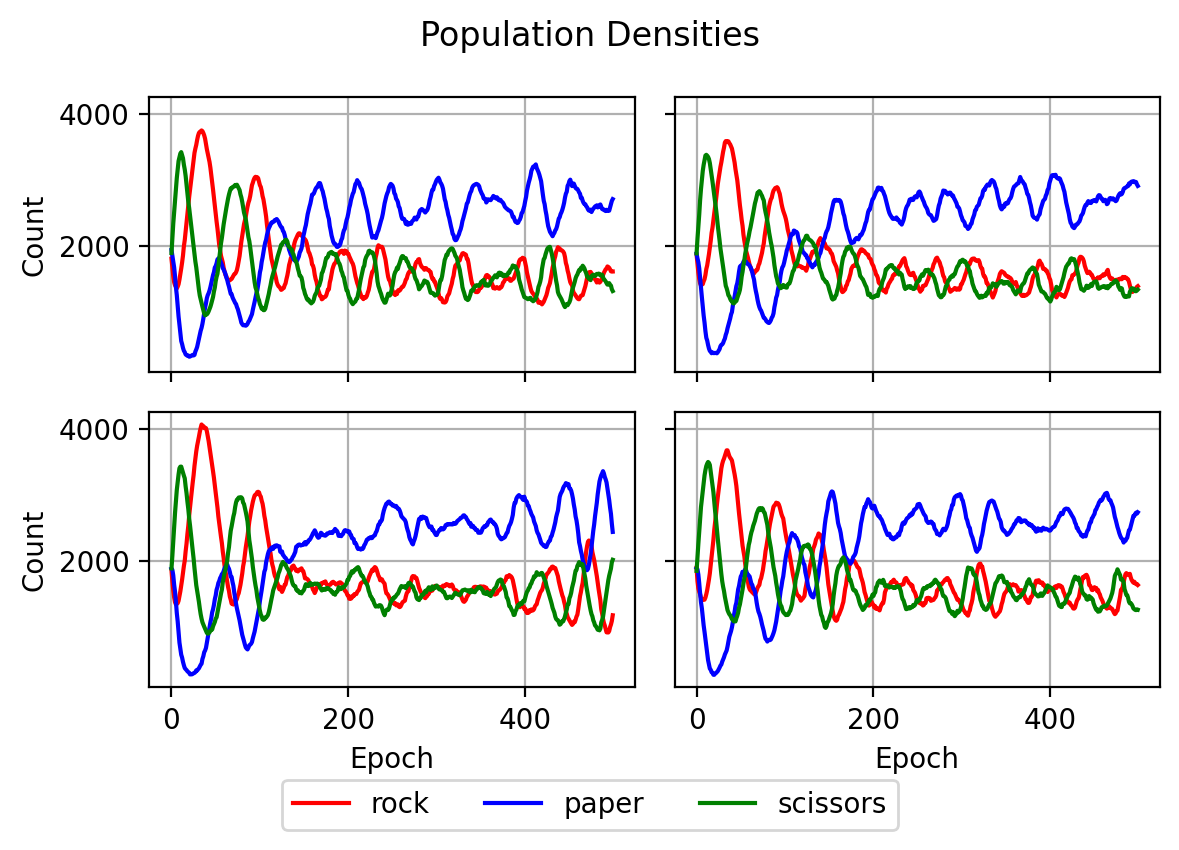

In [8]:
plot_densities(s1_df)

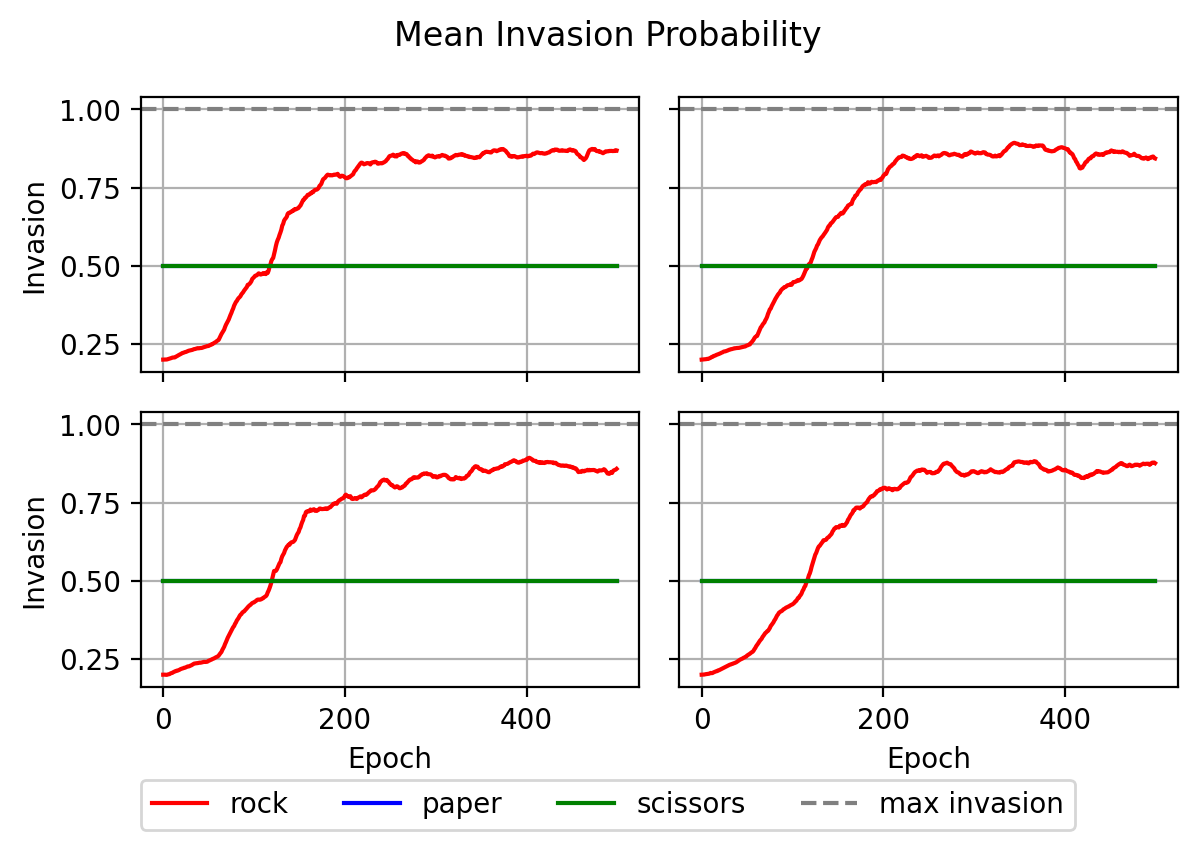

In [9]:
plot_average_invasions(s1_df)

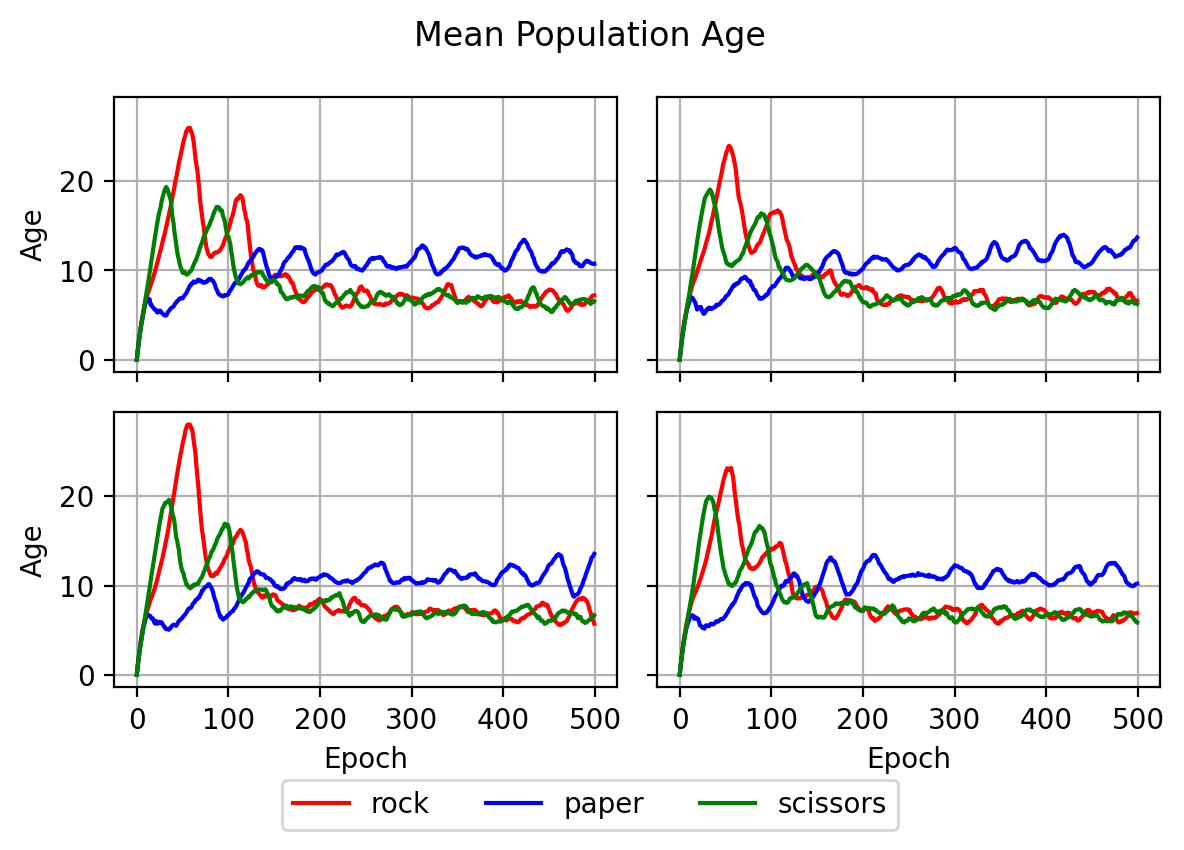

In [10]:
plot_average_age(s1_df)

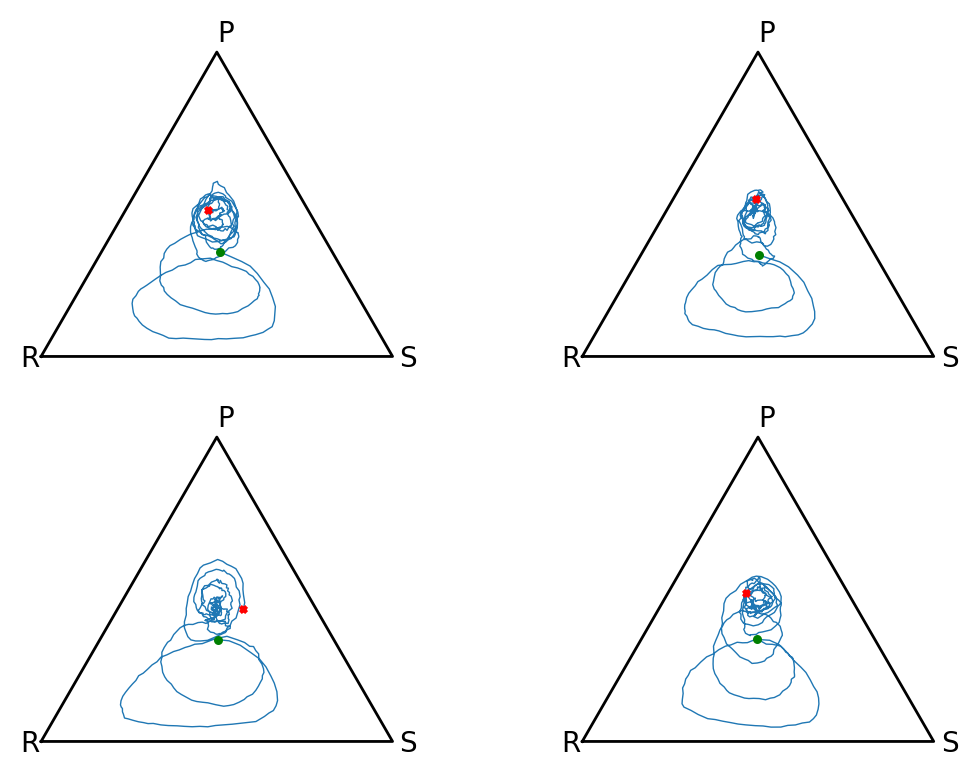

In [11]:
plot_orbits(s1_df)

Also for this setup nothing really surprising: since rock starts with a low
invasion probability, its population grows fast but more aggressive over time.

After few iterations the invasion rate is already at $0.5$ and after a few more
reaches values between $0.8$ and $0.9$ that, depending on the specific case,
leads to a decrease in population

### Stochastic Mutation of 3 Species

Another experiment consists in let all three species evolve via random
mutations, in the paper is mentioned how an equilibrium through maximal
aggression should be reached. 

It follows just a simulation in which every specie starts with an invasion
probability of $0.5$.

In [12]:
s3_df = pd.read_csv("results/stochastic3.csv")
s3_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1,790,868,842,0.501372,0.500332,0.499548,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
2,774,843,883,0.502400,0.498933,0.500422,1.874677,1.867141,1.842582,2,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
3,777,828,895,0.502907,0.498998,0.500429,2.574003,2.609903,2.572067,3,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
4,787,834,879,0.502436,0.499762,0.500926,3.180432,3.251799,3.285552,4,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,540,967,993,0.877663,0.872091,0.864158,6.179630,6.412616,4.744209,495,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1996,530,896,1074,0.873684,0.872488,0.859470,5.709434,6.458705,4.833333,496,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1997,526,830,1144,0.875531,0.872967,0.860435,5.250951,6.449398,5.000000,497,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1998,559,745,1196,0.874273,0.874730,0.861548,4.867621,6.363758,5.193980,498,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05


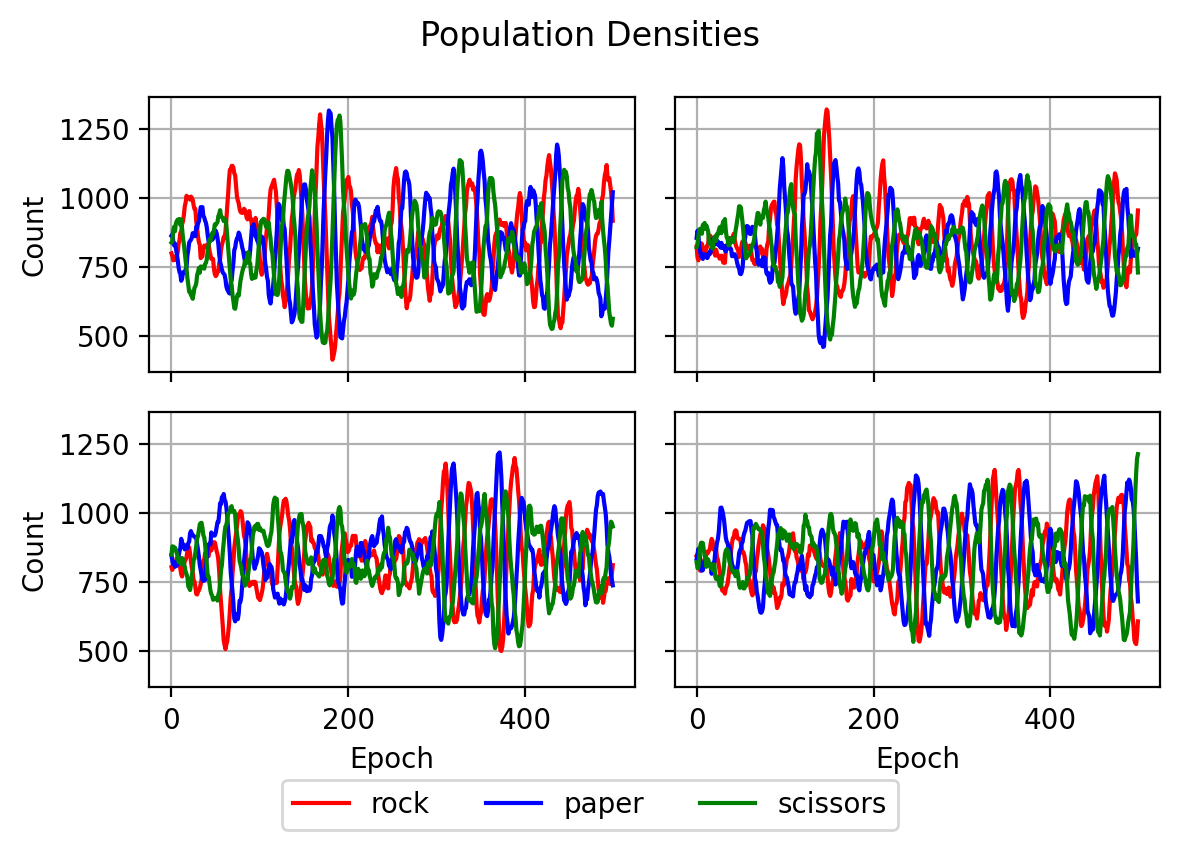

In [13]:
plot_densities(s3_df)

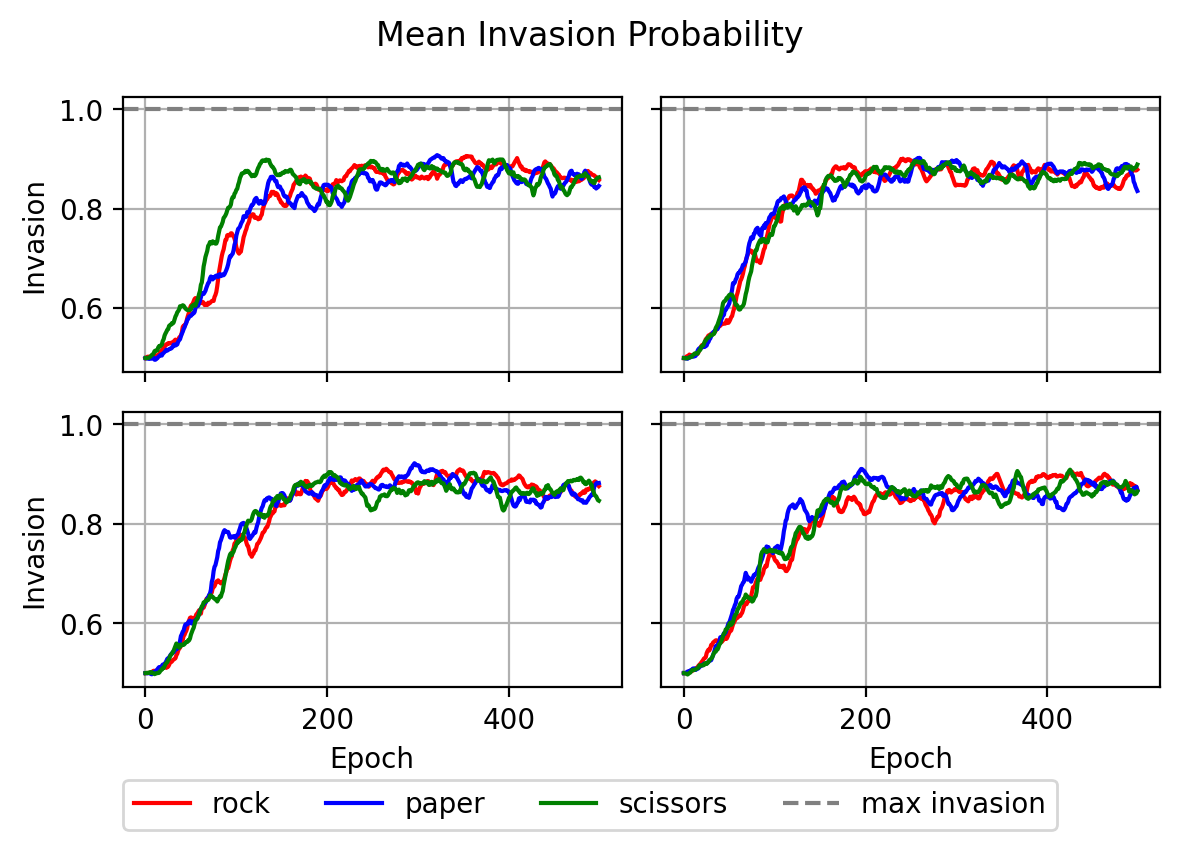

In [14]:
plot_average_invasions(s3_df)

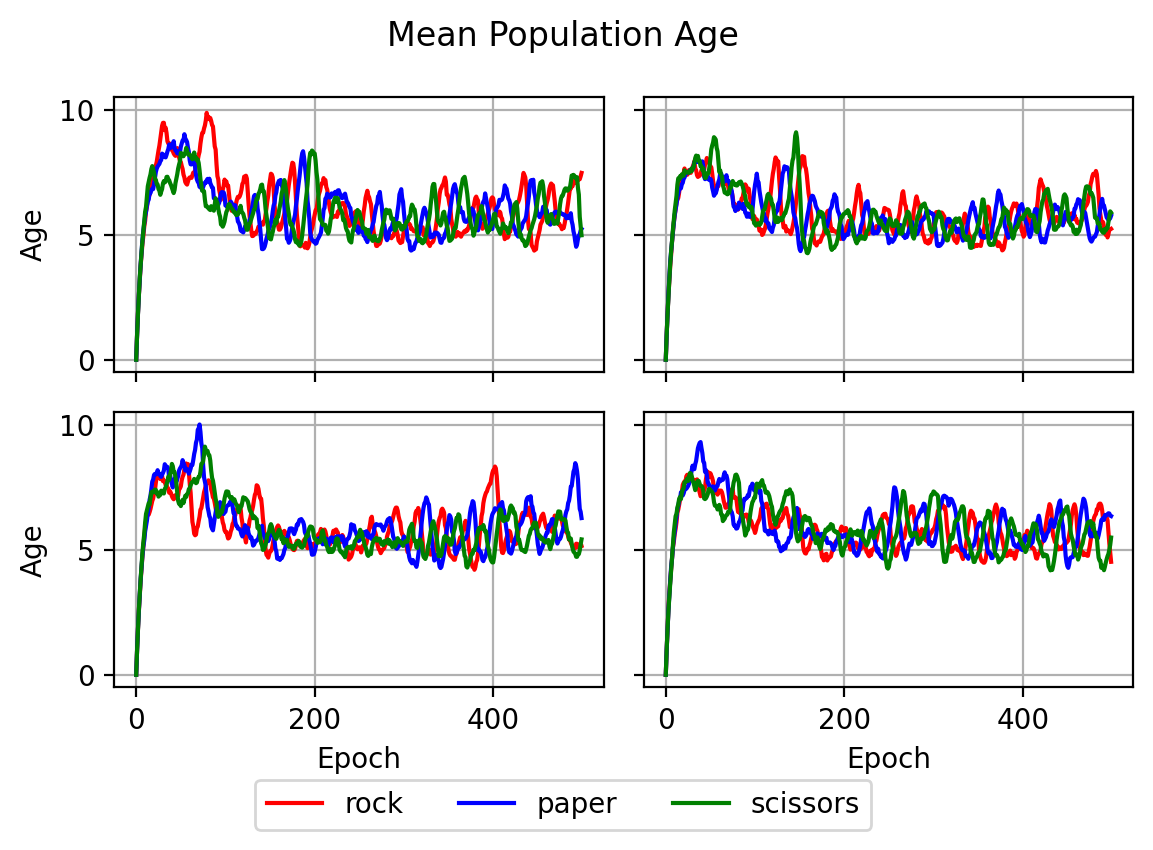

In [15]:
plot_average_age(s3_df)

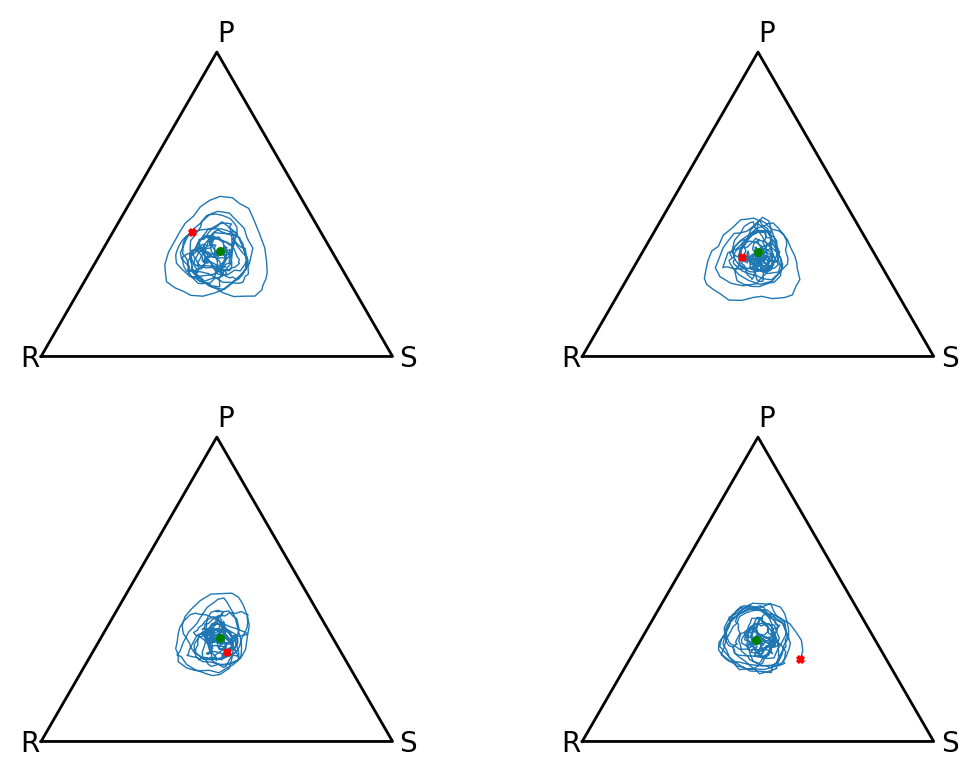

In [16]:
plot_orbits(s3_df)

## Proposed Extension

The proposed extension tries to introduce a more structured evolution approach,
by adding a **mating** mechasism based on a _fitness_ value (the age) and the
distance from the predator.

The idea is based on the assumption that older individuals may have a better
survival strategy. Therefore, when an individual hunts a prey, produces an
offspring with a invasion rate computed as the weighted mean between its
father's and a nearby individual with (hopefully) high fitness.

The idea is to sample an individual of the same specie within a certain radius
in order to maintain the simulation dynamics local. The final mate for
reproduction is sampled, weighted by its fitness.

The candidates are chosen within the radius accordingly with the Chebyshev
distance, which basically defines squared rings around the individual.

![Chebyshev Distance](images/chebyshev_distance.png)

### Genetic vs Stochastic

The other comparison was done by letting two of the species evolve by stochastic
mutations, while the third was optimized with the genetic approach.

In [17]:
g1_2s_df = pd.read_csv("results/genetic3_s2.csv")
g1_2s_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1,780,866,854,0.500403,0.499488,0.500132,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
2,778,823,899,0.500517,0.500039,0.500329,1.863753,1.872418,1.829811,2,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
3,780,801,919,0.500957,0.500158,0.499801,2.597436,2.630462,2.589771,3,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
4,797,786,917,0.501021,0.500173,0.501751,3.193225,3.267176,3.249727,4,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1001,649,850,0.676407,0.815556,0.838548,6.825175,5.859784,6.932941,495,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1996,1020,657,823,0.678004,0.819565,0.840106,6.776471,5.669711,6.867558,496,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1997,1020,663,817,0.678621,0.823487,0.840072,6.866667,5.574661,6.784578,497,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1998,1015,649,836,0.678226,0.826492,0.837689,7.016749,5.520801,6.570574,498,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10


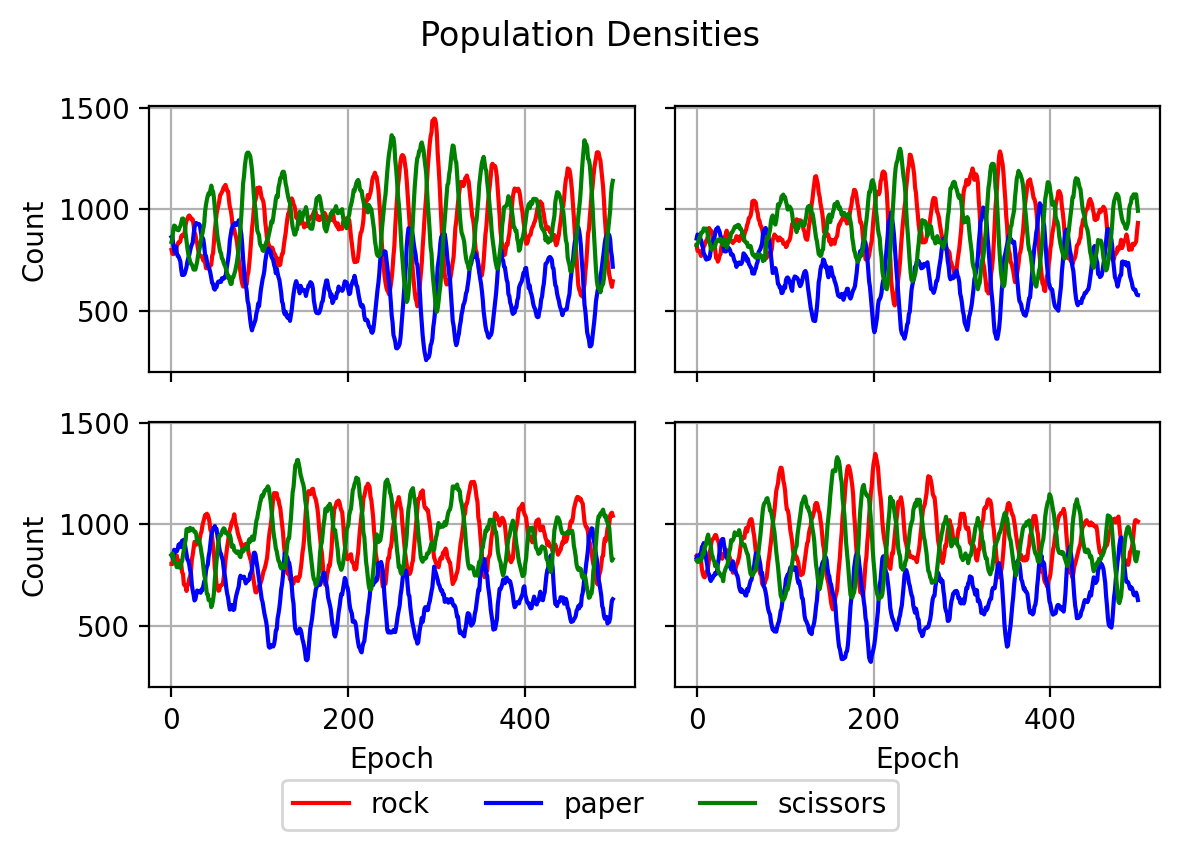

In [18]:
plot_densities(g1_2s_df)

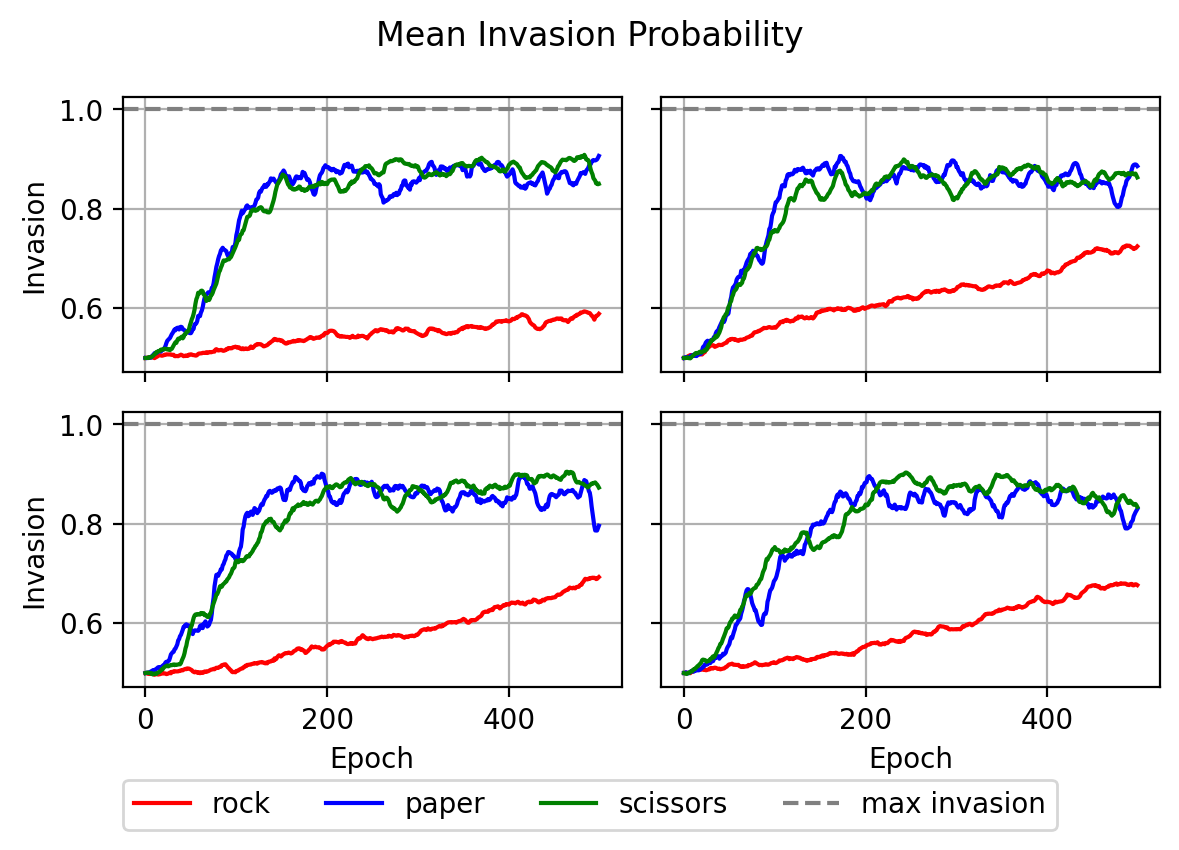

In [19]:
plot_average_invasions(g1_2s_df)

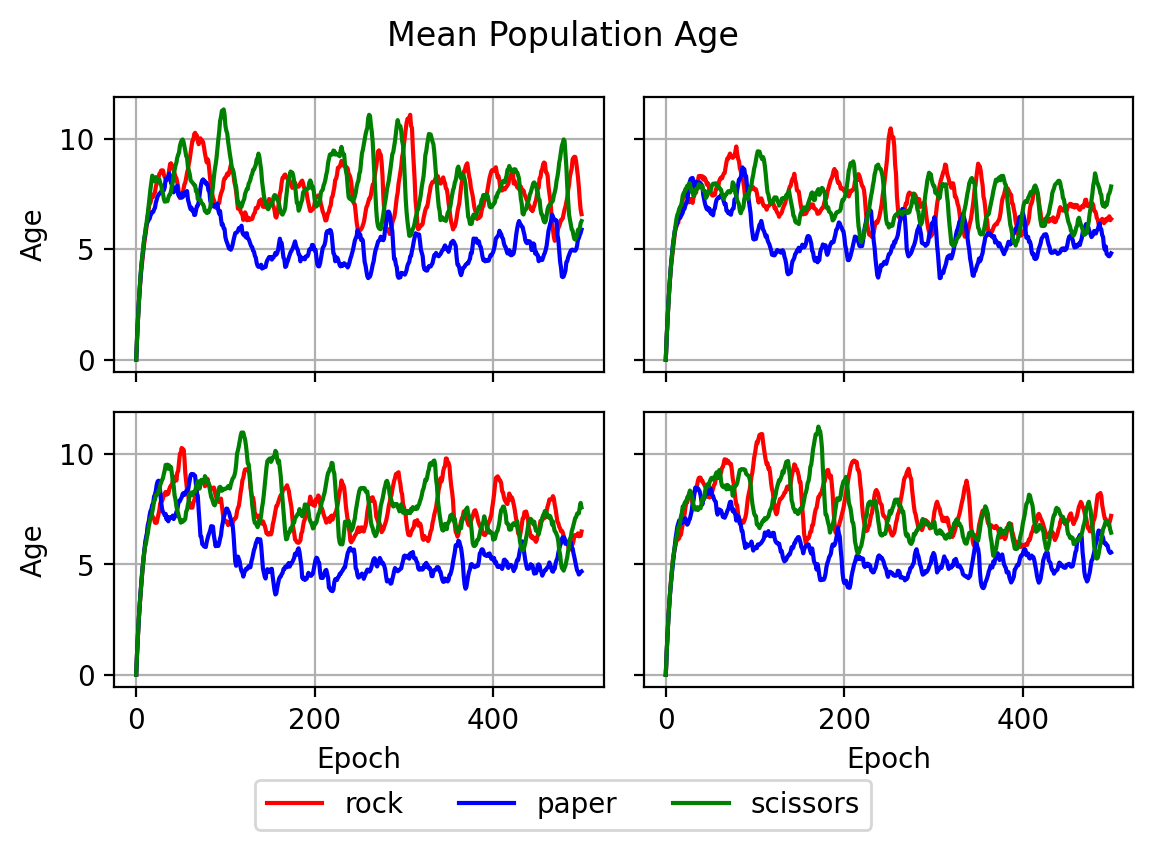

In [20]:
plot_average_age(g1_2s_df)

### Genetic with Radius 10

For the next experiment all three species are "optimized" with the genetic
evolution strategy, all starting with an initial invasion probability of $0.5$
and a **mating radius** of $10$.

In [21]:
g3_r10_df = pd.read_csv("results/genetic3_r10.csv")
g3_r10_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1,773,869,858,0.499807,0.499916,0.500509,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
2,790,841,869,0.500042,0.499636,0.501086,1.840506,1.869203,1.845800,2,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
3,802,811,887,0.499921,0.499785,0.501310,2.577307,2.646116,2.580609,3,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
4,856,792,852,0.500354,0.499092,0.501880,3.158879,3.347222,3.265258,4,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1033,886,581,0.552364,0.556169,0.545440,9.074540,7.357788,7.641997,495,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1996,986,922,592,0.553613,0.554193,0.543990,9.310345,7.390456,7.508446,496,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1997,958,939,603,0.553878,0.552675,0.544516,9.346555,7.560170,7.412935,497,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1998,919,986,595,0.554948,0.552696,0.544728,9.346028,7.589249,7.205042,498,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10


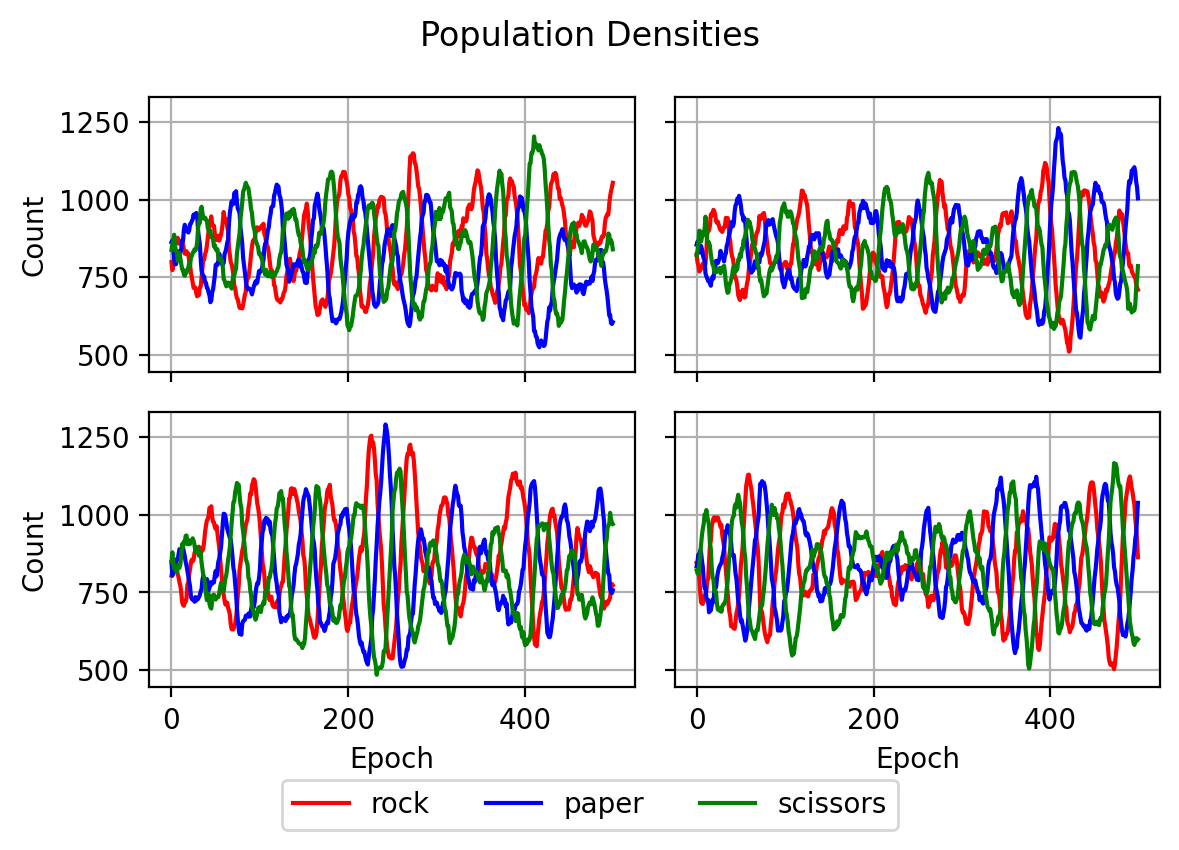

In [22]:
plot_densities(g3_r10_df)

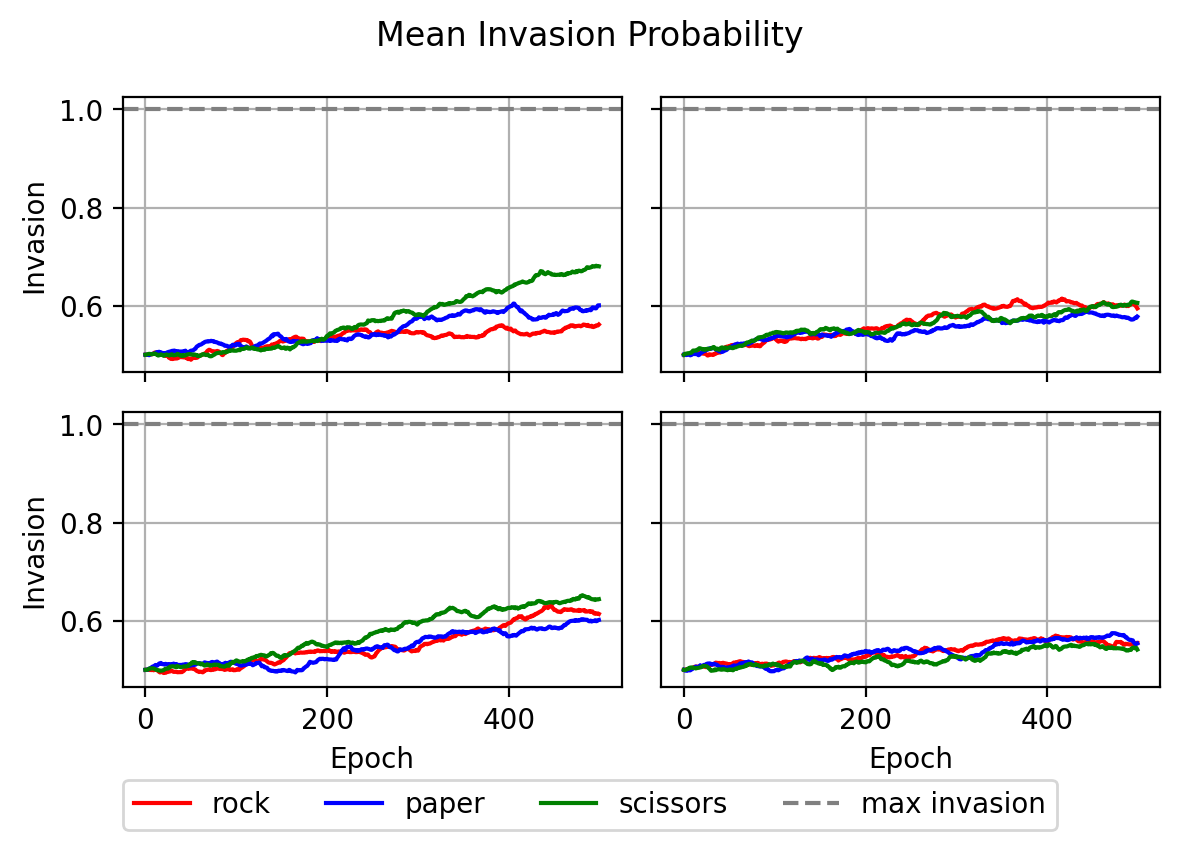

In [23]:
plot_average_invasions(g3_r10_df)

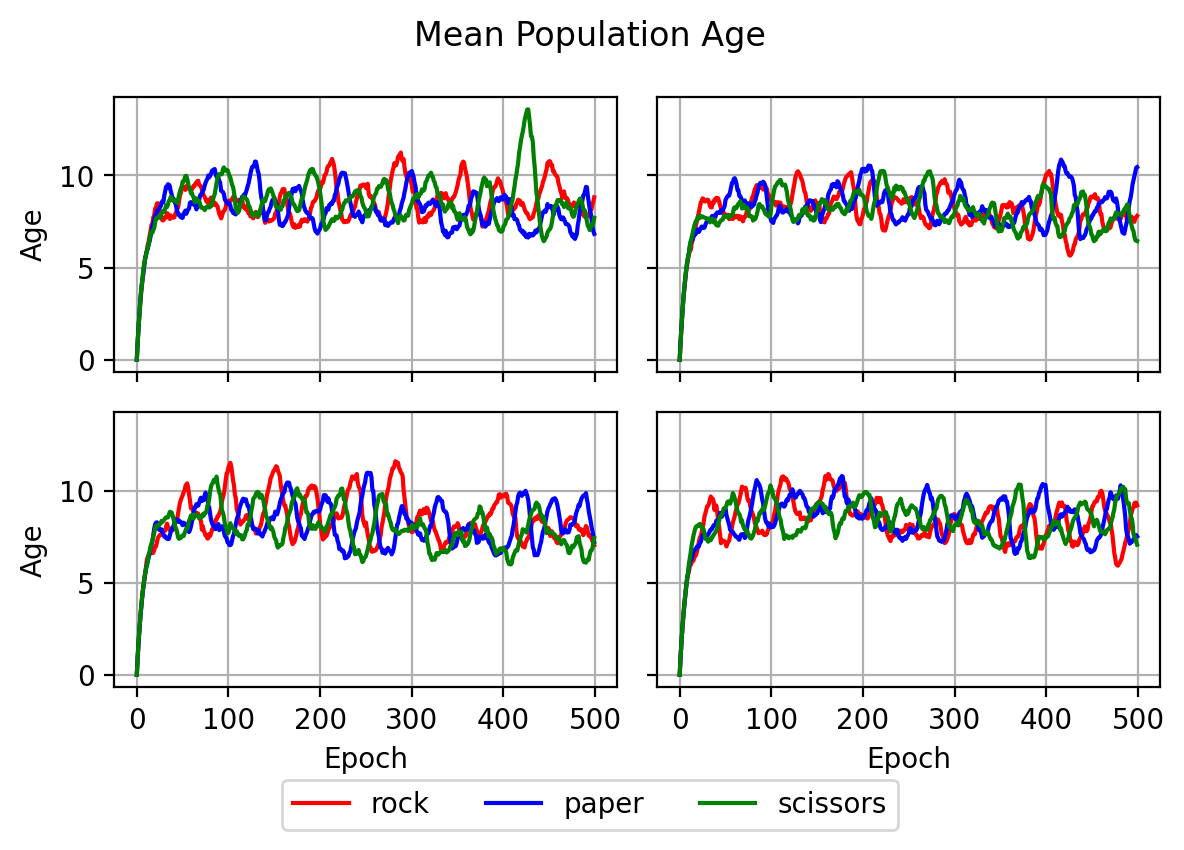

In [24]:
plot_average_age(g3_r10_df)

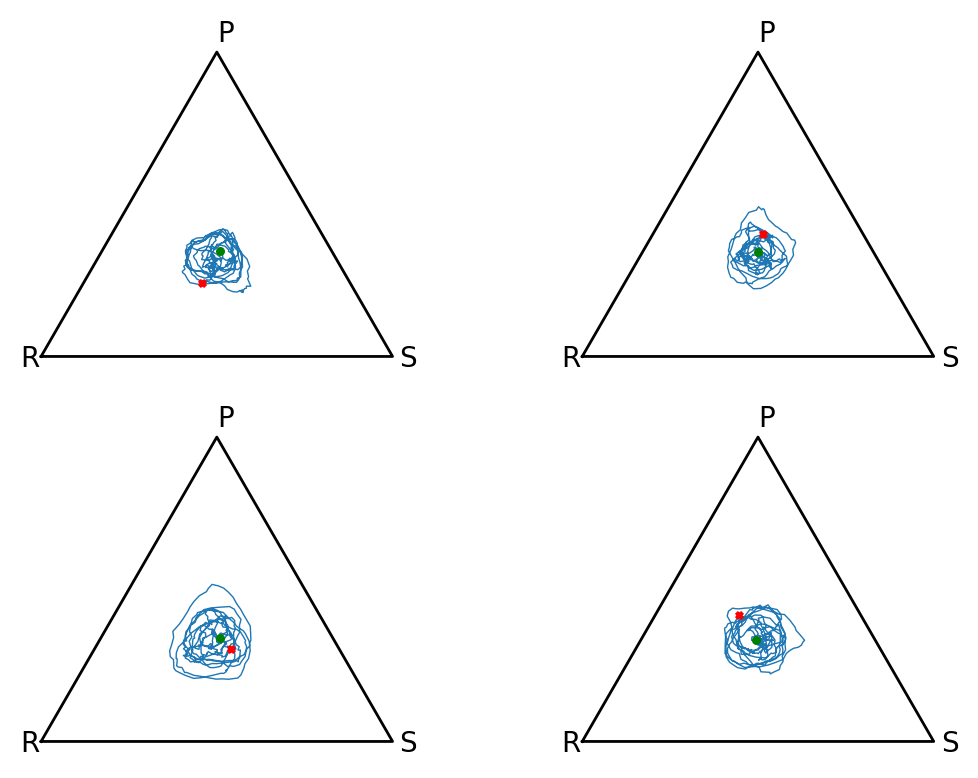

In [25]:
plot_orbits(g3_r10_df)

### Genetic with Radius 20

In [26]:
g3_r20_df = pd.read_csv("results/genetic3_r20.csv")
g3_r20_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1,773,869,858,0.499699,0.499889,0.500596,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
2,785,843,872,0.500873,0.499733,0.501500,1.842038,1.865955,1.845183,2,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
3,784,823,893,0.500800,0.500000,0.501870,2.567602,2.599028,2.569989,3,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
4,826,807,867,0.500645,0.498785,0.502410,3.184019,3.314746,3.256055,4,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,667,741,1092,0.589864,0.623762,0.605007,6.485757,7.630229,7.849817,495,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1996,673,718,1109,0.589775,0.624703,0.606103,6.591382,7.486072,7.885482,496,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1997,703,686,1111,0.589459,0.624847,0.606745,6.510669,7.572886,8.107111,497,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1998,728,669,1103,0.589641,0.627286,0.605730,6.414835,7.476831,8.258386,498,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20


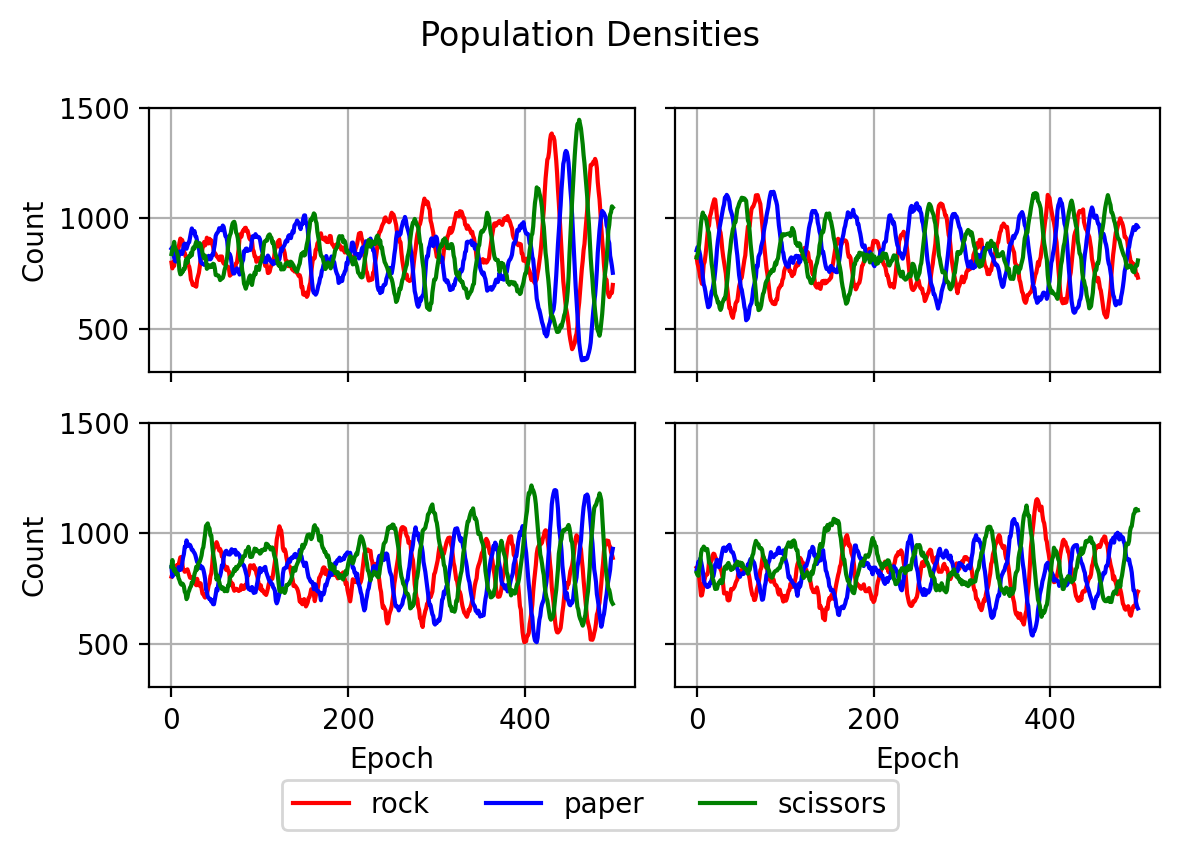

In [27]:
plot_densities(g3_r20_df)

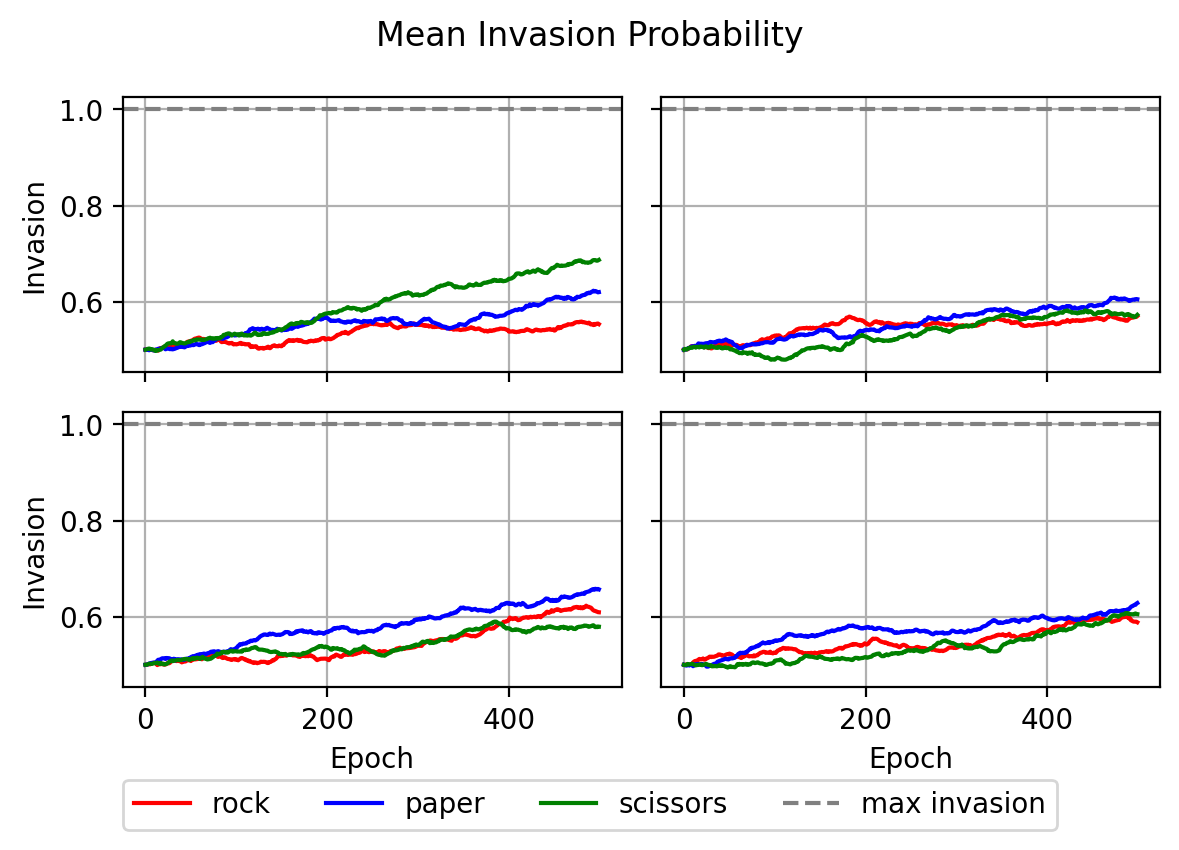

In [28]:
plot_average_invasions(g3_r20_df)

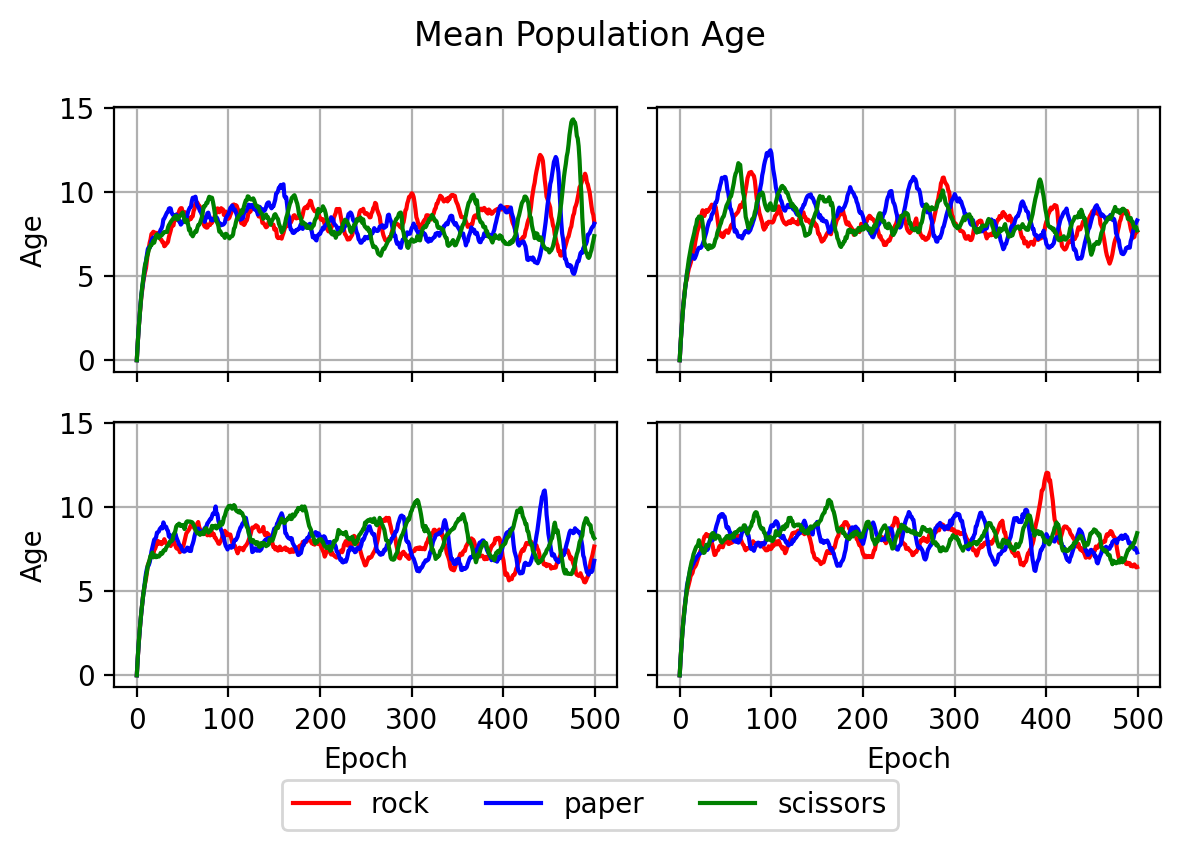

In [29]:
plot_average_age(g3_r20_df)

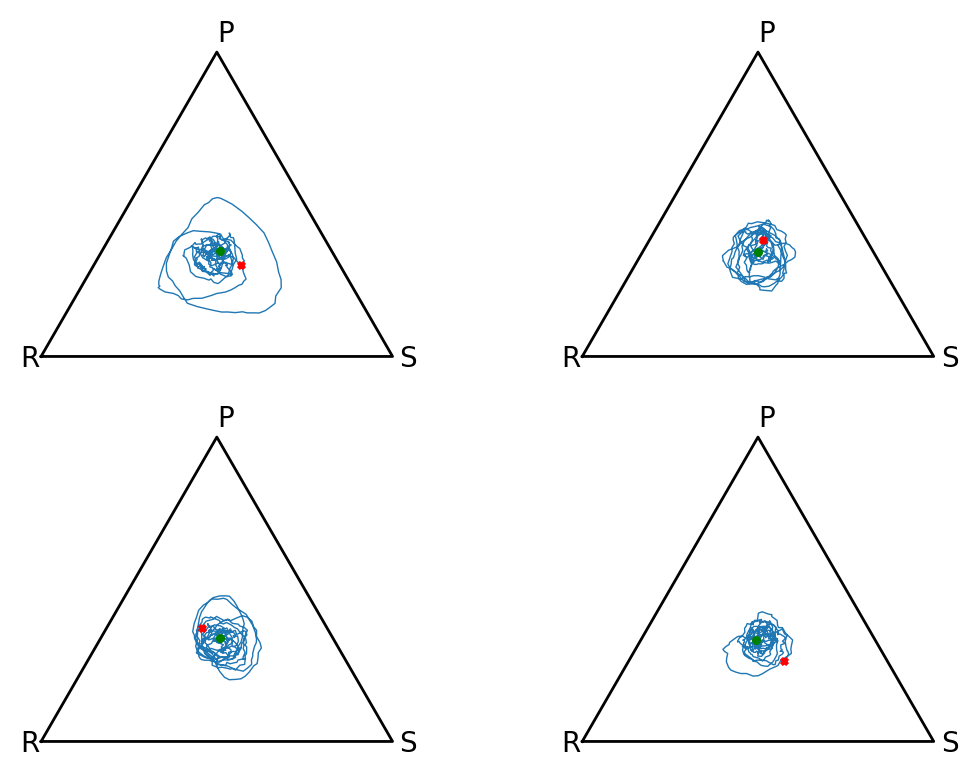

In [30]:
plot_orbits(g3_r20_df)

## Measures

From this work the most interesting things to measure are

- The correlation between age and invasion probability.
- Possible effect of mating radius different sizes.
- Convergence values for age and invasion probability compared to stochastic
  approach.

### Convergence Values of Age and Invasion

For the sake of simplicity the convergence values are just computed as the mean
among same simulations but with different seeds.

### Different Radius Effect

The radius length has the effect of amplify the probability of mating with an
high fitness individual.

### Age-Invasion Correlation

In [ ]:
print("stochastic invasion-age correlation")
print(f"rock: {s3_df['R_invasion'].corr(s3_df['R_age'])}")
print(f"paper: {s3_df['P_invasion'].corr(s3_df['P_age']):.4f}")
print(f"scissors: {s3_df['S_invasion'].corr(s3_df['S_age']):.4f}")

print()
print("genetic invasion-age correlation")
print(f"rock: {g3_r10_df['R_invasion'].corr(g3_r10_df['R_age']):.4f}")
print(f"paper: {g3_r10_df['P_invasion'].corr(g3_r10_df['P_age']):.4f}")
print(f"scissors: {g3_r10_df['S_invasion'].corr(g3_r10_df['S_age']):.4f}")

stochastic invasion-age correlation
rock: -0.41224743766265526
paper: -0.4366
scissors: -0.4299

genetic invasion-age correlation
rock: -0.0373
paper: 0.0268
scissors: -0.0450
